In [2]:
import sys
!{sys.executable} -m pip install -q torch matplotlib scikit-learn numpy

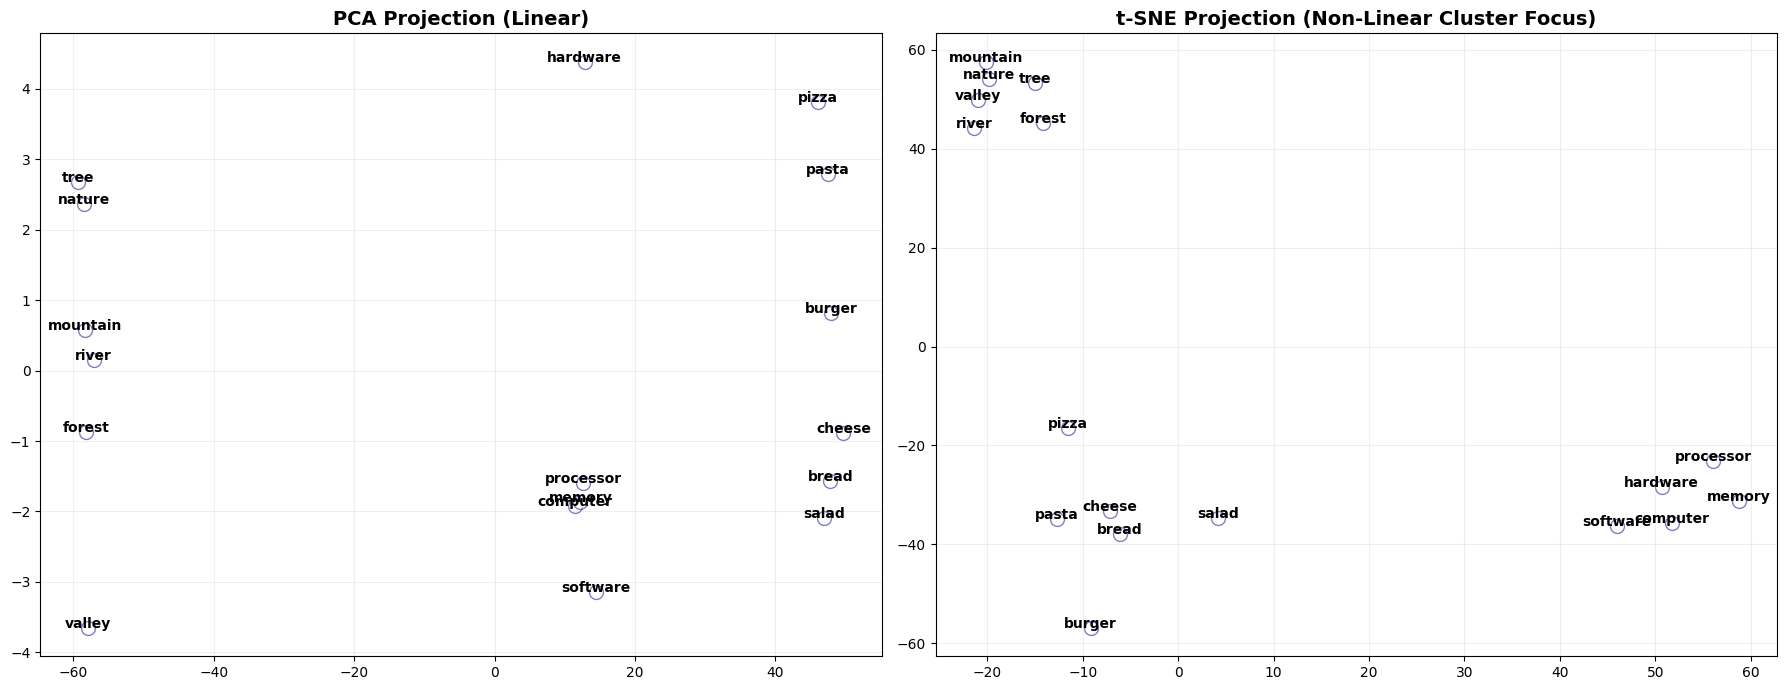

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# --- 1. Themed Dataset for Clustering ---
corpus = [
    "processor memory computer software hardware", # Tech
    "forest river mountain tree valley nature",   # Nature
    "pizza burger pasta bread salad cheese"        # Food
]

words = " ".join(corpus).split()
vocab = sorted(list(set(words)))
word_to_ix = {w: i for i, w in enumerate(vocab)}
vocab_size = len(vocab)

# --- 2. Create Random High-Dim Embeddings ---
# In a real scenario, these come from a trained model like Word2Vec.
# Here we simulate 'learned' embeddings with small shifts to ensure clusters.
torch.manual_seed(42)
embedding_dim = 50
embeddings = torch.randn(vocab_size, embedding_dim)

# Artificially shift 'themes' to simulate learned semantic proximity
for i, word in enumerate(vocab):
    if word in corpus[0]: embeddings[i] += 5.0  # Shift Tech cluster
    if word in corpus[1]: embeddings[i] -= 5.0  # Shift Nature cluster
    if word in corpus[2]: embeddings[i] += 10.0 # Shift Food cluster (farther)

# --- 3. Dimensionality Reduction (PCA vs t-SNE) ---
# PCA: Captures global structure
pca_coords = PCA(n_components=2).fit_transform(embeddings.numpy())

# t-SNE: Captures local clusters (Better for non-linear structures)
tsne_coords = TSNE(n_components=2, perplexity=5, random_state=42, init='pca').fit_transform(embeddings.numpy())

# --- 4. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

def plot_embeds(ax, coords, title):
    ax.scatter(coords[:, 0], coords[:, 1], s=100, c='white', edgecolors='navy', alpha=0.5)
    for i, word in enumerate(vocab):
        ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=10, fontweight='bold', ha='center')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.2)

plot_embeds(ax1, pca_coords, "PCA Projection (Linear)")
plot_embeds(ax2, tsne_coords, "t-SNE Projection (Non-Linear Cluster Focus)")

plt.tight_layout()
plt.show()